# CNN Handwritten Digit Recognition

This notebook builds a **Convolutional Neural Network (CNN)** that classifies handwritten digits (0–9) from the MNIST dataset, then wraps the trained model in an **interactive Streamlit app** where a user can draw a digit and get a live prediction.

**Steps overview:**
1. Import libraries
2. Load the MNIST dataset
3. Normalize and reshape the data
4. Define the CNN architecture
5. Train the model
6. Evaluate test accuracy
7. Visualize training vs. validation accuracy
8. Visualize training vs. validation loss
9. Save the trained model
10. Launch an interactive drawing app for live predictions


# Step 1: Import Libraries

This project uses:

- **TensorFlow / Keras** — to build, train, and save the CNN model
- **NumPy** — for array and numerical operations on the image data
- **Matplotlib** — to plot training/validation accuracy and loss curves

`datasets`, `layers`, and `models` are imported directly from `tensorflow.keras` for convenient access to the MNIST dataset and the model-building API.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models

# Step 2: Loading the Dataset

We use the **MNIST dataset**, a benchmark dataset of 70,000 grayscale images of handwritten digits (0–9), each sized 28×28 pixels.

- `x_train` / `y_train`: 60,000 training images and their corresponding digit labels
- `x_test` / `y_test`: 10,000 test images and labels, held out for evaluating generalization

The dataset comes bundled with Keras (`datasets.mnist.load_data()`), so no manual download is required.

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print('Training Images :', x_train.shape)
print('Training Labels :', y_train.shape)
print('Testing Images  :', x_test.shape)
print('Testing Labels  :', y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


- Display some sample pictures from Training Data

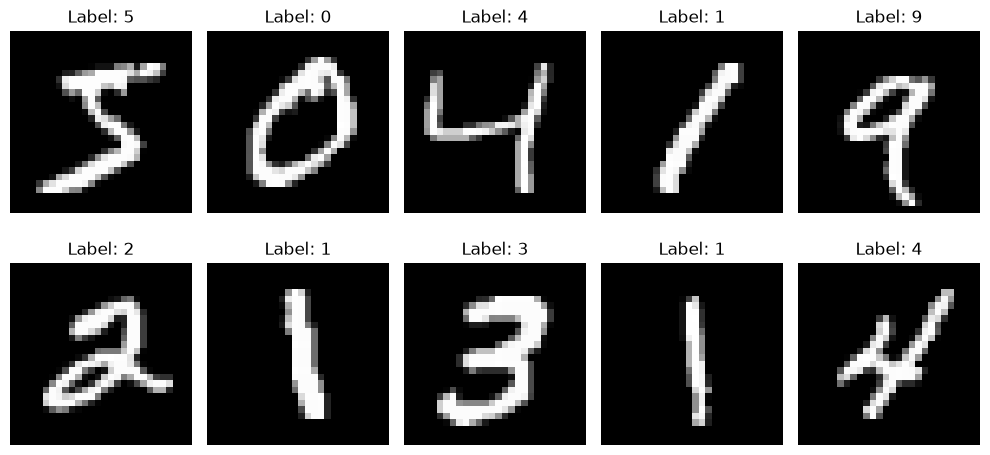

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Step 3: Preprocessing the Data

Two preprocessing steps are applied before training:

1. **Normalization** — pixel values are scaled from the raw `0–255` range to `0–1` by dividing by 255. This helps the network train faster and more stably.
2. **Reshaping** — images are reshaped from `(28, 28)` to `(28, 28, 1)`, adding an explicit channel dimension (1 for grayscale) since Keras's `Conv2D` layers expect input in `(height, width, channels)` format.

After this step, `x_train` has shape `(60000, 28, 28, 1)` and `x_test` has shape `(10000, 28, 28, 1)`.

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


# Step 4: Building the CNN Architecture

The model is a sequential CNN with the following layers:

| Layer | Details | Purpose |
|---|---|---|
| Conv2D | 32 filters, 3×3 kernel, ReLU | Learns low-level features (edges, curves) |
| MaxPooling2D | 2×2 pool | Downsamples, reduces spatial size and computation |
| Conv2D | 64 filters, 3×3 kernel, ReLU | Learns higher-level, more complex features |
| MaxPooling2D | 2×2 pool | Further downsampling |
| Flatten | — | Converts 2D feature maps into a 1D vector |
| Dense | 64 units, ReLU | Fully connected layer for classification logic |
| Dropout | 0.5 | Randomly disables 50% of neurons during training to reduce overfitting |
| Dense | 10 units, Softmax | Outputs a probability distribution over the 10 digit classes (0–9) |

**Compilation settings:**
- Optimizer: `adam`
- Loss: `sparse_categorical_crossentropy` (suitable since labels are integers, not one-hot encoded)
- Metric: `accuracy`

In [5]:
model = tf.keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\gurle\OneDrive\Desktop\Handwritten_Digit_Recog_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

# Step 5: Training the Model

The model is trained for **10 epochs** using `model.fit()`, with the test set passed in as `validation_data` so we can monitor generalization performance after every epoch.

During training, Keras prints the training loss/accuracy and validation loss/accuracy for each epoch, which lets us watch for overfitting (validation accuracy plateauing or dropping while training accuracy keeps climbing).

In [6]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9087 - loss: 0.2943 - val_accuracy: 0.9825 - val_loss: 0.0520
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9622 - loss: 0.1248 - val_accuracy: 0.9866 - val_loss: 0.0427
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9717 - loss: 0.0914 - val_accuracy: 0.9893 - val_loss: 0.0331
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9776 - loss: 0.0749 - val_accuracy: 0.9884 - val_loss: 0.0356
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9805 - loss: 0.0652 - val_accuracy: 0.9909 - val_loss: 0.0322
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9823 - loss: 0.0580 - val_accuracy: 0.9904 - val_loss: 0.0283
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9857 - loss: 0.0489 - val_accuracy: 0.9905 - val_loss: 0.0274
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9862 - loss: 0

# Step 6: Evaluating Model Accuracy on Test Data

`model.evaluate()` runs the trained model on the held-out test set (`x_test`, `y_test`) — data it has never seen during training — and reports the final **test loss** and **test accuracy**.

This is the most reliable measure of how well the model will generalize to new, real-world handwritten digits.

In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9937 - loss: 0.0235
Test Loss: 0.023523399606347084
Test Accuracy: 0.9937000274658203


# Step 7: Plotting for Training vs. Validation Accuracy

This plot compares accuracy on the training set against accuracy on the validation (test) set across all 10 epochs.

- If both curves rise together and stay close, the model is generalizing well.
- If training accuracy keeps rising while validation accuracy stalls or drops, that's a sign of **overfitting**.

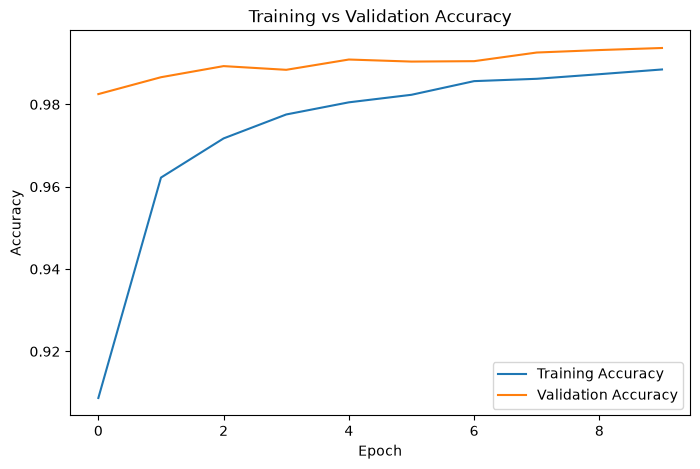

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

# Step 8. Plotting for Training v/s Validation Loss

This plot compares loss on the training set against loss on the validation set across all 10 epochs.

- Both curves should trend downward.
- A validation loss that starts increasing while training loss keeps decreasing is a clearer overfitting signal than the accuracy plot alone.

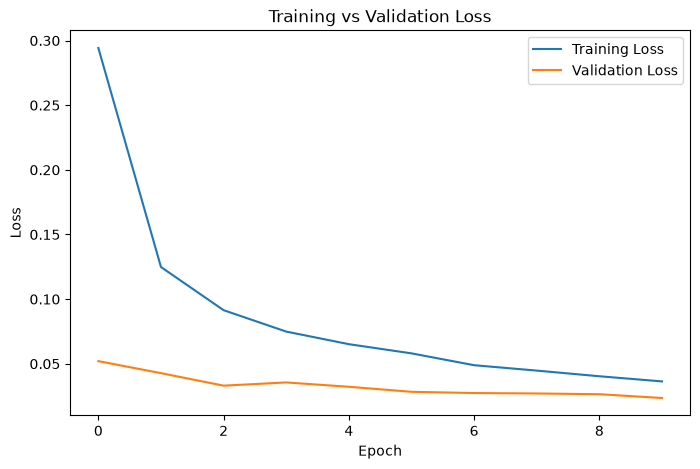

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

# Step 9. Saving the model using '.keras' extension

The trained model is saved to `model/digit_recognizer.keras` using Keras's native '.keras' format, which packages the architecture, weights, and optimizer state into a single file.

This saved model is what the Streamlit app loads in the next step to make predictions on user-drawn digits — training does not need to be repeated.

In [12]:
# model.save('model/digit_recognizer.keras')
# print('Model saved to model/digit_recognizer.keras')

model.save("digit_recognizer.keras")
print("Model saved")

Model saved


# Step 10: Interactive Streamlit Drawing App
The final cell writes and launches a **Streamlit** web app that lets you draw a digit by hand and see the model's prediction in real time.

**How it works:**
1. The app loads the saved model from `model/digit_recognizer.keras`
2. A drawable canvas (via `streamlit_drawable_canvas`) captures your input
3. The drawing is resized to 28×28, normalized, and reshaped to match the model's expected input
4. The model predicts the digit and displays the result along with confidence scores

**Requirements:** `streamlit` and `streamlit-drawable-canvas` must be installed (`pip install streamlit streamlit-drawable-canvas`). Run the next cell to launch the app locally.

In [14]:
import os
import subprocess
import sys
from pathlib import Path

app_code = """
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
from streamlit_drawable_canvas import st_canvas

# Configure the Streamlit page (browser tab title, icon, and centered layout)
st.set_page_config(page_title='Handwritten Digit Recognition', page_icon='🔢', layout='centered')

# Cache the model so it's loaded from disk only once per session,
# not re-loaded every time the app reruns (e.g. on button click)
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("digit_recognizer.keras")

model = load_model()

# App title and instructions
st.title('🔢 Handwritten Digit Recognition')
st.write('Draw a digit (0-9) below and click Predict.')

# Drawable canvas widget where the user sketches a digit
# - white strokes on a black background mimic MNIST's image style
# - 280x280 gives a large drawing area, later downscaled to 28x28 for the model
canvas_result = st_canvas(
    fill_color='blue',
    stroke_width=15,
    stroke_color='white',
    background_color='black',
    width=280,
    height=280,
    drawing_mode='freedraw',
    key='canvas',
)

# Only run prediction logic when the user clicks the "Predict" button
if st.button('Predict'):
    if canvas_result.image_data is not None:

        # Convert the canvas's raw pixel array (RGBA) into a PIL Image
        img = Image.fromarray(canvas_result.image_data.astype('uint8'))

        # Convert to grayscale ('L' mode) since the model expects single-channel input
        img = img.convert('L')

        # Resize down to 28x28 to match the MNIST input size
        img = img.resize((28, 28))

        img = np.array(img)               # convert to numpy array for numerical processing
        img = img / 255.0                 # normalize pixel values to [0, 1] range
        img = img.reshape(1, 28, 28, 1)   # reshape to (1, 28, 28, 1): batch of 1, single channel

        # Run the model on the preprocessed image
        prediction = model.predict(img, verbose=0)

        # predicted digit is the class with the highest probability
        digit = np.argmax(prediction)
        confidence = np.max(prediction)

        # Display the results
        st.success(f'Predicted Digit: {digit}')
        st.metric('Confidence', f'{confidence * 100:.2f}%')
        st.subheader('Prediction Probabilities')
        st.bar_chart(prediction[0])

    else:                                  # when no drawing is detected
        st.warning('Please draw a digit first.')
"""


app_path = Path('streamlit_digit_app.py')
app_path.write_text(app_code, encoding='utf-8')

print('Launching Streamlit app...')
subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', str(app_path), '--server.headless', 'true'])
print('Open the local Streamlit URL shown below.')
print('http://localhost:8501')

Launching Streamlit app...
Open the local Streamlit URL shown below.
http://localhost:8501
